Colunas lidas: ['aluno_id', 'horas_estudo_semana', 'faltas', 'media_simulados', 'aprovado']


,aluno_id,horas_estudo_semana,faltas,media_simulados,aprovado
0,1,2,10,7,0
1,2,9,14,70,0
2,3,15,14,97,0
3,4,7,1,91,1
4,5,9,0,23,0



Distribuição do target:
aprovado
0    691
1    109
Name: count, dtype: int64
Total linhas válidas: 800

Treino: 640 | Teste: 160

=== Random Forest ===
Acurácia: 0.90625

Relatório:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       138
           1       0.68      0.59      0.63        22

    accuracy                           0.91       160
   macro avg       0.81      0.77      0.79       160
weighted avg       0.90      0.91      0.90       160

Matriz de confusão (real x previsto):
[[132   6]
 [  9  13]]

Importância das variáveis:
media_simulados: 0.3472
horas_estudo_semana: 0.3386
faltas: 0.3142

=== Árvore de Decisão ===
Acurácia: 0.90625

Relatório:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       138
           1       0.77      0.45      0.57        22

    accuracy                           0.91       160
   macro avg       0.84      0.72      0.76       160
weigh

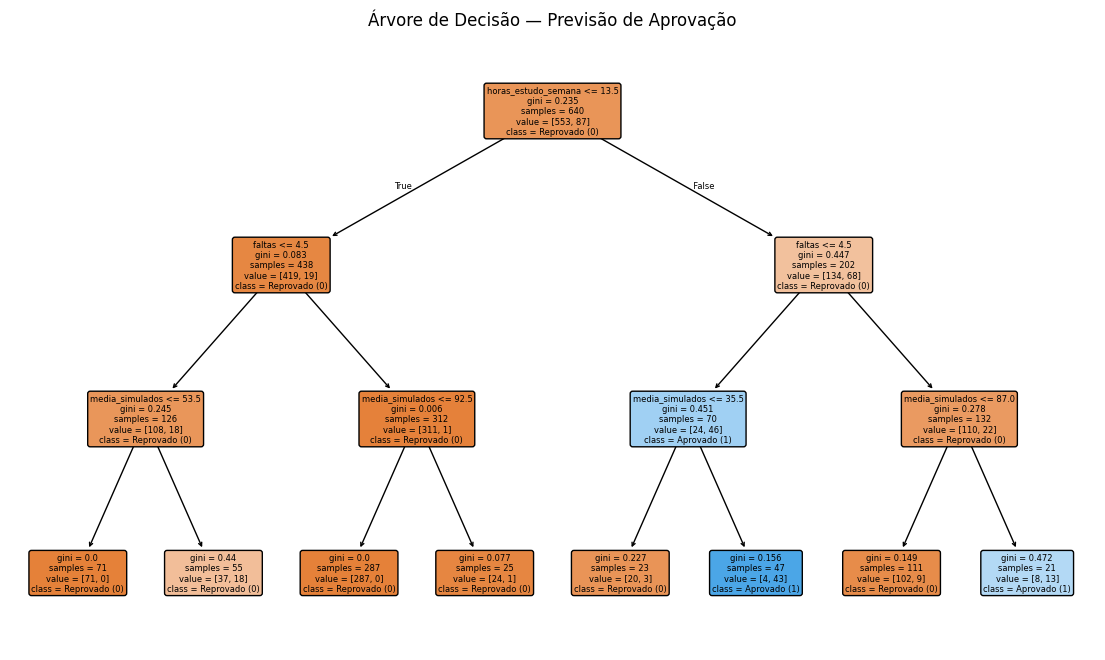

In [3]:
# -*- coding: utf-8 -*-
"""Aula001-VersaoMinimaParaTrabalho-Aprovacao-Alunos.ipynb"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ==========================================================
# 1) Leitura do dataset (Google Sheets - aba correta)
# ==========================================================

SHEET_ID = "1PiScPawV8qN_dzx3JqHWjTKYae8q07wm"
GID = "1334296780"  # aba correta

url_csv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&gid={GID}"

df = pd.read_csv(url_csv)

print("Colunas lidas:", list(df.columns))
display(df.head())

# ==========================================================
# 2) Definição das variáveis
# ==========================================================

FEATURES = [
    "horas_estudo_semana",
    "faltas",
    "media_simulados"
]

TARGET = "aprovado"

# Garantir tipo numérico
for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

# Remover linhas inválidas
df = df.dropna(subset=FEATURES + [TARGET]).copy()

print("\nDistribuição do target:")
print(df[TARGET].value_counts())
print("Total linhas válidas:", len(df))

# ==========================================================
# 3) Split Estratificado
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES].values,
    df[TARGET].values,
    test_size=0.20,
    random_state=42,
    stratify=df[TARGET].values
)

print("\nTreino:", len(X_train), "| Teste:", len(X_test))

# ==========================================================
# 4) Random Forest
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("\nRelatório:")
print(classification_report(y_test, y_pred_rf))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_rf))

# ==========================================================
# 5) Importância das variáveis
# ==========================================================

print("\nImportância das variáveis:")
importances = rf.feature_importances_

for f, imp in sorted(zip(FEATURES, importances), key=lambda x: x[1], reverse=True):
    print(f"{f}: {round(imp,4)}")

# ==========================================================
# 6) Árvore de Decisão
# ==========================================================

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de Decisão ===")
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# ==========================================================
# 7) Visualização da Árvore
# ==========================================================

plt.figure(figsize=(14, 8))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=["Reprovado (0)", "Aprovado (1)"],
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão — Previsão de Aprovação")
plt.show()